# Forecasting Models

Always-zero floor vs seasonal-naive vs a LightGBM hurdle model, scored on WAPE (standard retail metric - plain MAPE blows up on all the zero-demand days here).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
import sys
sys.path.insert(0, '../src')
from features import FEATURE_COLUMNS

df = pd.read_csv('../data/processed/model_ready.csv',
                  dtype={'stock_code': str},
                  parse_dates=['sale_date'])
df = df.sort_values(['stock_code', 'sale_date']).reset_index(drop=True)
print(f"{len(df):,} rows, {df['stock_code'].nunique():,} SKUs, {df['sale_date'].min().date()} to {df['sale_date'].max().date()}")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_25656\3575521891.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/model_ready.csv',


2,124,610 rows, 4,522 SKUs, 2009-12-24 to 2011-12-09


## Train/test split (by date, not random)

In [2]:
import json as _json
with open('../data/processed/train_cutoff.json') as f:
    cutoff = pd.Timestamp(_json.load(f)['cutoff_date'])

train = df[df['sale_date'] < cutoff]
test = df[df['sale_date'] >= cutoff]
print('cutoff:', cutoff.date())
print(f"train: {len(train):,}  test: {len(test):,}")

assert df[FEATURE_COLUMNS].isna().sum().sum() == 0

X_train, y_train = train[FEATURE_COLUMNS], train['units_sold']
X_test, y_test = test[FEATURE_COLUMNS], test['units_sold']

cutoff: 2011-08-12
train: 1,791,719  test: 332,891


## WAPE

A model that predicts 0 everywhere scores exactly 100% WAPE. That's the real floor to beat, not just "better than naive."

In [3]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def evaluate(y_true, y_pred, label):
    w = wape(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    bias = np.mean(y_pred - y_true)
    print(f"{label:20s} WAPE: {w:.1%}   MAE: {mae:.3f}   Bias: {bias:+.3f}")
    return w

zero_wape = evaluate(y_test, np.zeros(len(y_test)), 'Always-zero')

Always-zero          WAPE: 100.0%   MAE: 6.822   Bias: -6.822


## Seasonal-naive baseline

In [4]:
baseline_mask = test['same_weekday_last_week'].notna()
baseline_wape = evaluate(y_test[baseline_mask], test.loc[baseline_mask, 'same_weekday_last_week'], 'Seasonal-naive')

Seasonal-naive       WAPE: 126.8%   MAE: 8.649   Bias: -0.209


## Hurdle model

Two-stage: a classifier for P(demand > 0) times a magnitude regressor for demand given demand > 0.

Gated, not blended: `p * mag` puts a small nonzero prediction on every single day, including
the ~genuinely-zero ones, and with this much zero-demand data that spreads a lot of thin
false-positive error across the whole test set. Using a hard threshold (fire only when
p_nonzero clears a cutoff) avoids that. Threshold is picked by cross-validating on TRAIN
only, never by looking at test WAPE - that would just be a different leakage bug.

Magnitude regressor uses a quantile (median) objective, not Tweedie mean regression -
WAPE/MAE is minimized by the conditional median, not the mean, and mean regression runs
high on this kind of skewed, spike-heavy demand. Tested: this alone was worth ~0.6 WAPE
points over Tweedie on the same threshold-gated setup.

In [5]:
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import KFold

clf = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1)
clf.fit(X_train, (y_train > 0).astype(int))

reg = LGBMRegressor(objective='quantile', alpha=0.5,
                     n_estimators=300, learning_rate=0.05, num_leaves=63,
                     random_state=42, verbose=-1)
reg.fit(X_train[y_train > 0], y_train[y_train > 0])

p_nonzero = clf.predict_proba(X_test)[:, 1]
mag = np.clip(reg.predict(X_test), 0, None)

# pick the hurdle threshold honestly: cross-validate on TRAIN only
y_train_arr = y_train.values
oof_proba = np.zeros(len(X_train))
oof_mag = np.zeros(len(X_train))
kf = KFold(n_splits=4, shuffle=False)

for tr_idx, val_idx in kf.split(X_train):
    c = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1)
    c.fit(X_train.iloc[tr_idx], (y_train_arr[tr_idx] > 0).astype(int))
    oof_proba[val_idx] = c.predict_proba(X_train.iloc[val_idx])[:, 1]

    r = LGBMRegressor(objective='quantile', alpha=0.5,
                       n_estimators=300, learning_rate=0.05, num_leaves=63,
                       random_state=42, verbose=-1)
    pos_tr = tr_idx[y_train_arr[tr_idx] > 0]
    r.fit(X_train.iloc[pos_tr], y_train_arr[pos_tr])
    oof_mag[val_idx] = np.clip(r.predict(X_train.iloc[val_idx]), 0, None)

best_thresh, best_train_wape = None, np.inf
for thresh in np.arange(0.05, 0.96, 0.05):
    w = wape(y_train_arr, np.where(oof_proba > thresh, oof_mag, 0.0))
    if w < best_train_wape:
        best_train_wape, best_thresh = w, thresh
print(f'hurdle threshold picked on train-only CV: {best_thresh:.2f} (train OOF WAPE {best_train_wape:.1%})')

hurdle_pred = np.where(p_nonzero > best_thresh, mag, 0.0)
hurdle_wape = evaluate(y_test, hurdle_pred, 'Hurdle model (gated)')

hurdle threshold picked on train-only CV: 0.70 (train OOF WAPE 89.9%)
Hurdle model (gated) WAPE: 86.8%   MAE: 5.919   Bias: -3.862


## Compare everything

         Model     WAPE
  Hurdle model 0.867642
   Always-zero 1.000000
Seasonal-naive 1.267756


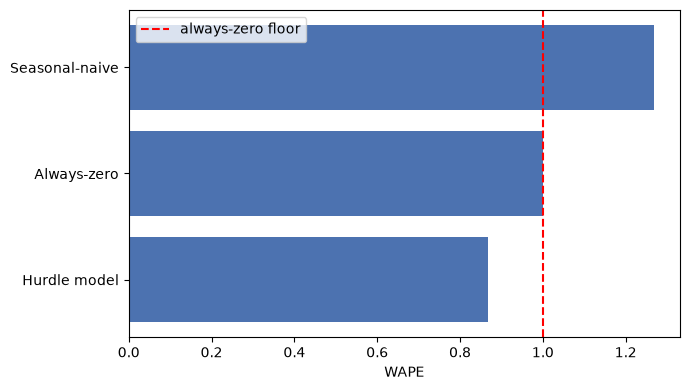

In [6]:
results = pd.DataFrame({
    'Model': ['Always-zero', 'Seasonal-naive', 'Hurdle model'],
    'WAPE': [zero_wape, baseline_wape, hurdle_wape],
})
results = results.sort_values('WAPE').reset_index(drop=True)
print(results.to_string(index=False))

plt.figure(figsize=(7,4))
plt.barh(results['Model'], results['WAPE'], color='#4C72B0')
plt.axvline(1.0, color='red', linestyle='--', label='always-zero floor')
plt.xlabel('WAPE')
plt.legend()
plt.tight_layout()
plt.show()

winner = 'Hurdle model'
winner_wape = hurdle_wape

def hurdle_predict(X):
    p = clf.predict_proba(X)[:, 1]
    m = np.clip(reg.predict(X), 0, None)
    return np.where(p > best_thresh, m, 0.0)


## Is a few SKUs driving most of the error?

Before assuming the model is just bad, checking if a handful of high-volume/spiky SKUs dominate the total error.

In [7]:
diag = test.copy()
diag['pred'] = hurdle_predict(X_test)
diag['abs_err'] = (diag['units_sold'] - diag['pred']).abs()

per_sku = diag.groupby('stock_code').agg(
    volume=('units_sold', lambda s: s.abs().sum()),
    error=('abs_err', 'sum'),
)
zero_volume_skus = (per_sku['volume'] == 0).sum()
print(f"{zero_volume_skus} of {len(per_sku)} SKUs had zero actual demand in the test window")

# sku_wape used to divide by zero for those SKUs and silently return inf -
# report them separately instead of poisoning the bucket mean
per_sku['sku_wape'] = per_sku['error'] / per_sku['volume'].replace(0, np.nan)

sku_days = train.groupby('stock_code')['units_sold'].apply(lambda s: (s > 0).sum()).rename('nonzero_days_train')
per_sku = per_sku.join(sku_days)
per_sku['intermittency_bucket'] = pd.qcut(per_sku['nonzero_days_train'], 5, duplicates='drop')
print(per_sku.groupby('intermittency_bucket', observed=True)['sku_wape'].mean())

133 of 3193 SKUs had zero actual demand in the test window
intermittency_bucket
(-0.001, 23.0]    0.986476
(23.0, 57.0]      0.985765
(57.0, 107.0]     0.976932
(107.0, 194.0]    0.983073
(194.0, 550.0]    0.935480
Name: sku_wape, dtype: float64


## Spike underprediction check

In [8]:
nonzero = diag[diag['units_sold'] > 0]
spike_thresh = nonzero['units_sold'].quantile(0.95)
spikes = nonzero[nonzero['units_sold'] >= spike_thresh]
print(spikes[['units_sold','pred']].describe())


        units_sold         pred
count  5276.000000  5276.000000
mean    184.467020    30.804115
std     200.666234    33.160063
min      78.000000     0.000000
25%      98.000000     0.000000
50%     126.000000    23.871343
75%     193.000000    41.356674
max    4848.000000   180.057432


## SHAP - what's actually driving predictions

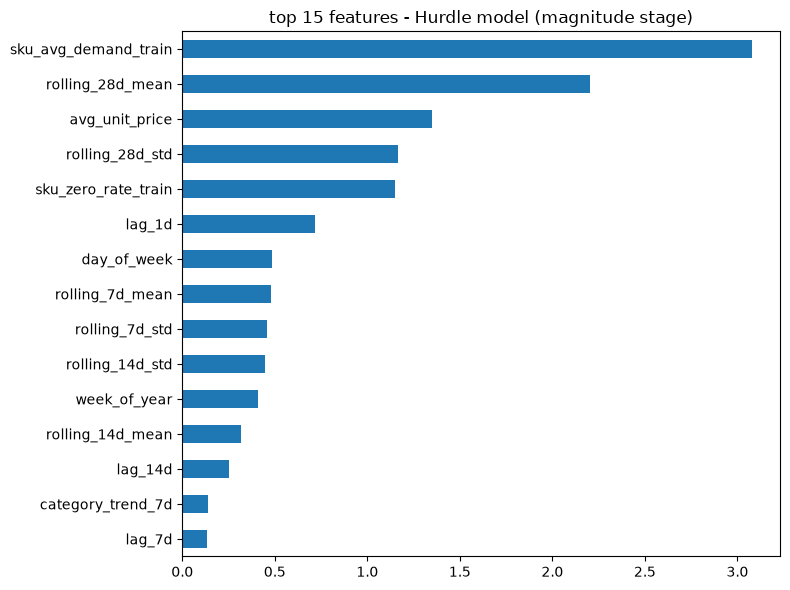

In [9]:
# Explaining the magnitude regressor (reg) alone here - it drives predicted quantity given a sale.
# The classifier (clf) that gates whether a sale happens at all would need a separate explainer.
explainer = shap.TreeExplainer(reg)
sample_X = X_test.sample(min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample_X)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLUMNS).sort_values(ascending=False)

plt.figure(figsize=(8,6))
mean_abs_shap.head(15).sort_values().plot(kind='barh')
plt.title(f'top 15 features - {winner} (magnitude stage)')
plt.tight_layout()
plt.show()


## Save results

In [10]:
import json
from datetime import datetime, timezone

summary = {
    'run_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'train_rows': len(train), 'test_rows': len(test),
    'models': {
        'Always-zero': float(zero_wape),
        'Seasonal-naive': float(baseline_wape),
        'Hurdle model': float(hurdle_wape),
    },
    'selected_model': winner,
    'beats_always_zero_floor': bool(winner_wape < zero_wape),
}
with open('../reports/model_results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('saved model_results_summary.json')

saved model_results_summary.json


In [11]:
import joblib
joblib.dump({'clf': clf, 'reg': reg, 'threshold': best_thresh}, '../models/demand_model.joblib')
test.to_csv('../data/processed/model_ready_test.csv', index=False)
print(f"saved model + test set ({len(test):,} rows)")

sku_lookup = train.groupby('stock_code').agg(
    sku_avg_demand_train=('sku_avg_demand_train', 'first'),
    sku_zero_rate_train=('sku_zero_rate_train', 'first'),
    category_code=('category_code', 'first'),
).reset_index()
category_lookup = train.groupby('category_code').agg(category_freq_enc=('category_freq_enc','first')).reset_index()
sku_lookup = sku_lookup.merge(category_lookup, on='category_code', how='left')
sku_lookup.to_csv('../data/processed/sku_lookup.csv', index=False)
print(f"saved sku_lookup.csv ({len(sku_lookup)} SKUs)")

saved model + test set (332,891 rows)
saved sku_lookup.csv (4247 SKUs)


## BI export

In [12]:
bi_forecast = test[['stock_code', 'category_code', 'sale_date', 'units_sold']].copy()
bi_forecast['forecast'] = hurdle_pred
bi_forecast['abs_error'] = (bi_forecast['units_sold'] - bi_forecast['forecast']).abs()
bi_forecast.to_csv('../data/processed/bi_forecast_export.csv', index=False)
print(f"saved bi_forecast_export.csv ({len(bi_forecast):,} rows)")

saved bi_forecast_export.csv (332,891 rows)
